# CrediScore — Analyse exploratoire

**Préparation des données — profilage des sources**
Auteur : Tagne Guylain Florian

Ce notebook explore les huit fichiers sources du projet et **établit les faits
sur lesquels le pipeline est construit**. Chaque section se termine par la
décision technique qu'elle a entraînée.

Les chiffres sont mesurés sur l'intégralité des données, sans échantillonnage,
sauf mention contraire. Les mêmes mesures sont produites par les scripts
`src/data/profile_raw.py`, `profile_joins.py` et `profile_quality.py`, qui
génèrent les documents de `docs/`.

---

## Ce que l'analyse a changé

| Découverte | Décision |
|---|---|
| 8,07 % de défauts | Métriques AUC-PR et coût métier, jamais l'accuracy |
| `installments` couvre 94,1 % des dossiers (et non 57,4 %) | Traitée en priorité n°1 |
| 653 483 « doublons » qui n'en sont pas | Consolidation avant agrégation |
| 55 374 valeurs sentinelles à 365243 | Neutralisation en `NULL` + indicateur |
| Divisions par zéro dans 5 des 7 ratios | Dénominateurs protégés |

---

## D'où viennent ces données

Le jeu de données existe en **deux exemplaires**, et ce notebook lit le premier :

| Emplacement | Lu par | Rôle |
|---|---|---|
| `input/` — sur le poste | **ce notebook** et les trois scripts de `src/data/` | Analyse exploratoire |
| `s3://crediscore-datalake-…/raw/` — sur AWS | le pipeline de production | Source de vérité |

Ce sont les **mêmes huit fichiers**, déposés dans le data lake le 30/07/2026.

L'analyse lit la copie locale parce qu'elle est instantanée, gratuite et
utilisable hors connexion — télécharger 2,5 Gio à chaque itération n'aurait
aucun sens. Le pipeline, lui, ne lit **que** S3 : c'est là que vit la donnée
source, chiffrée, versionnée, et **inaccessible en écriture même à la machine
qui la traite**.

> **Limite assumée.** Les tailles des deux copies correspondent, mais une taille
> identique n'est pas une preuve d'identité. Le pipeline enregistre pour cette
> raison une empreinte du lot traité dans `feature_store.journal_publication`,
> ce qui rattache chaque publication de variables aux données exactes dont elle
> est issue.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ENTREE = Path("../../input")

# --- Palette ---------------------------------------------------------------
# Huit teintes catégorielles validées pour la vision des couleurs (écart
# perceptuel suffisant, y compris en deutéranopie et protanopie), plus une
# palette d'état réservée aux seuls statuts. Une teinte d'état ne sert jamais
# de « série n°4 » : sa signification serait ambiguë.
BLEU, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
JAUNE, MAGENTA, VIOLET = "#eda100", "#e87ba4", "#4a3aa7"
BON, ALERTE, CRITIQUE = "#0ca30c", "#fab219", "#d03b3b"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]

ENCRE, ENCRE_2, ENCRE_3 = "#0b0b0b", "#52514e", "#8a8880"

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": ENCRE_3,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": ENCRE_2,
    "axes.titlecolor": ENCRE,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "text.color": ENCRE,
    "xtick.color": ENCRE_2,
    "ytick.color": ENCRE_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#e8e7e3",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "figure.dpi": 110,
    "font.size": 10,
})


def habiller(ax, titre, sous_titre=None, axe_x=None, axe_y=None, grille="y"):
    """Applique le titre, le sous-titre explicatif et une grille discrète."""
    ax.set_title(titre, pad=18 if sous_titre else 12)
    if sous_titre:
        ax.text(0, 1.02, sous_titre, transform=ax.transAxes,
                fontsize=9, color=ENCRE_2, va="bottom")
    ax.set_xlabel(axe_x or "")
    ax.set_ylabel(axe_y or "")
    if grille:
        ax.grid(axis=grille, alpha=0.7)
        ax.set_axisbelow(True)
    return ax


def espace(n=None):
    """Formate un entier avec des espaces fins comme séparateurs de milliers."""
    return f"{n:,}".replace(",", " ")


print("Palette et style prêts.")

Palette et style prêts.


---

## 1. La cible : un déséquilibre qui commande le choix des métriques

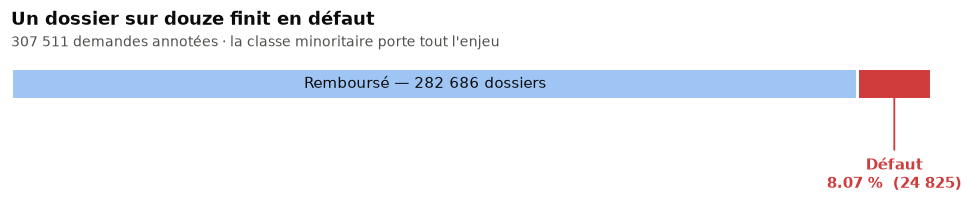

Rapport entre classes : 1 défaut pour 11.4 remboursements


In [2]:
cible = pd.read_csv(ENTREE / "application_train.csv", usecols=["TARGET"])["TARGET"]
n_total, n_defaut = len(cible), int(cible.sum())
taux = n_defaut / n_total * 100

fig, ax = plt.subplots(figsize=(9, 1.9))

# Forme retenue : une barre unique empilée. Le message est une PROPORTION entre
# deux catégories — pas une comparaison de grandeurs, ni une évolution. Un
# camembert rendrait le rapport 1:11 illisible ; deux barres côte à côte
# feraient perdre la notion de tout.
ax.barh([0], [100 - taux], color=SEQ[1], edgecolor="white", linewidth=2, height=0.5)
ax.barh([0], [taux], left=[100 - taux], color=CRITIQUE,
        edgecolor="white", linewidth=2, height=0.5)

ax.text(45, 0, f"Remboursé — {espace(n_total - n_defaut)} dossiers",
        va="center", ha="center", color=ENCRE, fontsize=10)
ax.annotate(f"Défaut\n{taux:.2f} %  ({espace(n_defaut)})",
            xy=(100 - taux / 2, 0), xytext=(100 - taux / 2, -1.15),
            ha="center", va="top", fontsize=10, color=CRITIQUE, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=CRITIQUE, lw=1.2))

ax.set_xlim(0, 100); ax.set_ylim(-1.6, 0.5)
ax.set_yticks([]); ax.set_xticks([])
for s in ax.spines.values():
    s.set_visible(False)
habiller(ax, "Un dossier sur douze finit en défaut",
         "307 511 demandes annotées · la classe minoritaire porte tout l'enjeu", grille=None)
plt.tight_layout(); plt.show()

print(f"Rapport entre classes : 1 défaut pour {(n_total - n_defaut) / n_defaut:.1f} remboursements")

**Ce que ça décide.** Avec 8 % de positifs, un modèle qui prédit « jamais de
défaut » atteint 92 % d'accuracy tout en étant parfaitement inutile. La métrique
d'évaluation sera donc l'**AUC-PR**, robuste au déséquilibre, et le seuil de
décision sera choisi par une **fonction de coût métier** — un défaut non détecté
coûte le capital prêté, un bon client refusé ne coûte qu'un manque à gagner.

---

## 2. Huit fichiers, trois systèmes sources

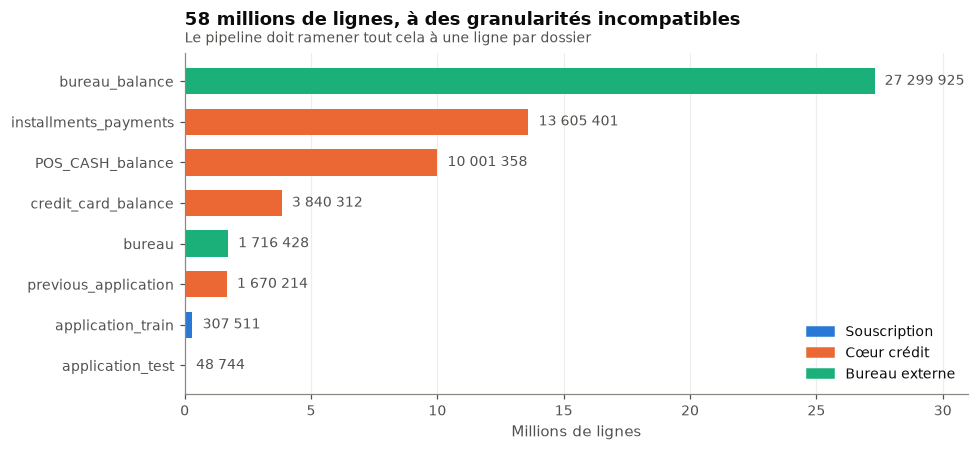

In [3]:
FICHIERS = {
    "installments_payments": "Cœur crédit",
    "bureau_balance": "Bureau externe",
    "credit_card_balance": "Cœur crédit",
    "previous_application": "Cœur crédit",
    "POS_CASH_balance": "Cœur crédit",
    "bureau": "Bureau externe",
    "application_train": "Souscription",
    "application_test": "Souscription",
}
LIGNES = {
    "installments_payments": 13_605_401, "bureau_balance": 27_299_925,
    "credit_card_balance": 3_840_312, "previous_application": 1_670_214,
    "POS_CASH_balance": 10_001_358, "bureau": 1_716_428,
    "application_train": 307_511, "application_test": 48_744,
}
COULEUR_SYSTEME = {"Souscription": BLEU, "Cœur crédit": ORANGE, "Bureau externe": AQUA}

donnees = (pd.DataFrame({"fichier": LIGNES.keys(), "lignes": LIGNES.values()})
           .assign(systeme=lambda d: d.fichier.map(FICHIERS))
           .sort_values("lignes"))

fig, ax = plt.subplots(figsize=(9, 4.2))

# Forme retenue : barres horizontales. On compare des GRANDEURS entre catégories
# nommées, et les noms sont longs — l'horizontale les rend lisibles sans les
# incliner. La couleur porte ici l'appartenance à un système source (identité),
# donc palette catégorielle et non séquentielle.
barres = ax.barh(donnees.fichier, donnees.lignes / 1e6,
                 color=[COULEUR_SYSTEME[s] for s in donnees.systeme], height=0.65)

for barre, valeur in zip(barres, donnees.lignes):
    ax.text(barre.get_width() + 0.4, barre.get_y() + barre.get_height() / 2,
            espace(valeur), va="center", fontsize=9, color=ENCRE_2)

poignees = [plt.Rectangle((0, 0), 1, 1, color=coul) for coul in COULEUR_SYSTEME.values()]
ax.legend(poignees, COULEUR_SYSTEME.keys(), loc="lower right", ncol=1)

ax.set_xlim(0, 31)
habiller(ax, "58 millions de lignes, à des granularités incompatibles",
         "Le pipeline doit ramener tout cela à une ligne par dossier",
         axe_x="Millions de lignes", grille="x")
plt.tight_layout(); plt.show()

**Ce que ça décide.** Une ligne d'`application_train` est un dossier ; une ligne
de `bureau_balance` est l'état mensuel d'un crédit détenu ailleurs. Joindre
directement dupliquerait chaque dossier des centaines de fois. **Chaque table
fille doit donc être agrégée au grain du dossier avant toute jointure.**

---

## 3. La couverture : l'écart qui a décidé l'ordre des traitements

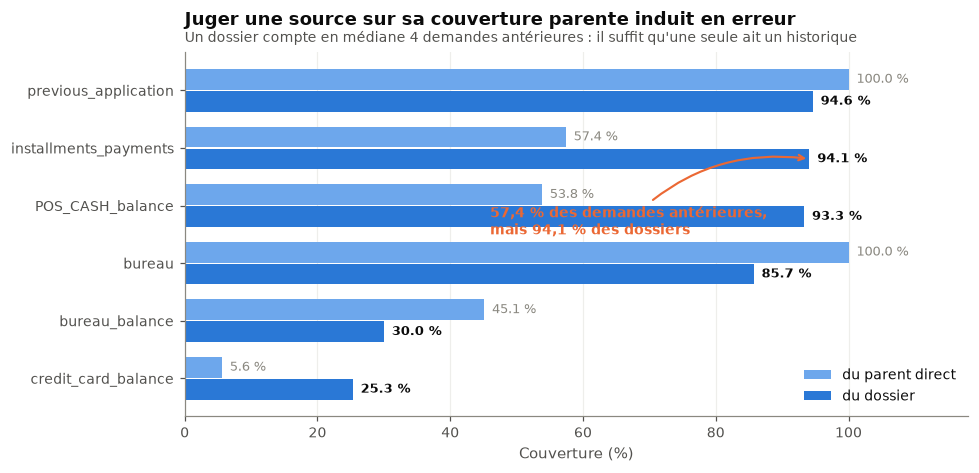

In [4]:
# Mesures issues de docs/schema_jointures.md, calculées sur l'intégralité des
# fichiers par src/data/profile_joins.py.
COUVERTURE = pd.DataFrame([
    ("previous_application", 100.0, 94.6),
    ("installments_payments", 57.4, 94.1),
    ("POS_CASH_balance", 53.8, 93.3),
    ("bureau", 100.0, 85.7),
    ("bureau_balance", 45.1, 30.0),
    ("credit_card_balance", 5.6, 25.3),
], columns=["source", "parent", "dossier"]).sort_values("dossier")

fig, ax = plt.subplots(figsize=(9, 4.4))
y = np.arange(len(COUVERTURE))

# Forme retenue : barres groupées, deux séries comparées sur la MÊME unité (un
# pourcentage). Un seul axe, donc — jamais deux échelles verticales, qui
# laisseraient croire à des rapports que les données ne portent pas.
ax.barh(y + 0.19, COUVERTURE.parent, height=0.36, color=SEQ[2], label="du parent direct")
ax.barh(y - 0.19, COUVERTURE.dossier, height=0.36, color=BLEU, label="du dossier")

for i, ligne in enumerate(COUVERTURE.itertuples()):
    ax.text(ligne.parent + 1.2, i + 0.19, f"{ligne.parent:.1f} %",
            va="center", fontsize=8.5, color=ENCRE_3)
    ax.text(ligne.dossier + 1.2, i - 0.19, f"{ligne.dossier:.1f} %",
            va="center", fontsize=8.5, color=ENCRE, fontweight="bold")

# Mise en évidence du cas qui a décidé de l'ordre du pipeline.
i_instal = list(COUVERTURE.source).index("installments_payments")
ax.annotate("57,4 % des demandes antérieures,\nmais 94,1 % des dossiers",
            xy=(94.1, i_instal - 0.19), xytext=(46, i_instal - 1.5),
            fontsize=9, color=ORANGE, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.4,
                            connectionstyle="arc3,rad=-0.25"))

ax.set_yticks(y); ax.set_yticklabels(COUVERTURE.source)
ax.set_xlim(0, 118); ax.legend(loc="lower right")
habiller(ax, "Juger une source sur sa couverture parente induit en erreur",
         "Un dossier compte en médiane 4 demandes antérieures : il suffit qu'une seule ait un historique",
         axe_x="Couverture (%)", grille="x")
plt.tight_layout(); plt.show()

**Ce que ça décide.** `installments_payments` ne couvre que 57,4 % des demandes
antérieures — de quoi la reléguer au second plan. Mais elle couvre **94,1 % des
dossiers**, parce qu'il suffit qu'une seule des demandes d'un client porte un
historique de paiement.

C'est la source qui décrit ce que le client **a fait**, et non ce qu'il déclare.
Elle est donc traitée **en premier** par le pipeline.

---

## 4. Les 653 483 « doublons » qui n'en sont pas

La mesure d'unicité a signalé 653 483 doublons de grain dans
`installments_payments` — et dans aucune des six autres tables. Un
`drop_duplicates()` réflexe aurait été une faute. Voici pourquoi.

In [5]:
instal = pd.read_csv(
    ENTREE / "installments_payments.csv",
    usecols=["SK_ID_PREV", "NUM_INSTALMENT_VERSION", "NUM_INSTALMENT_NUMBER",
             "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT", "AMT_INSTALMENT", "AMT_PAYMENT"],
)
CLES = ["SK_ID_PREV", "NUM_INSTALMENT_VERSION", "NUM_INSTALMENT_NUMBER"]

taille = instal.groupby(CLES).size()
fractionnees = taille[taille > 1]

print(f"Lignes du fichier          : {espace(len(instal))}")
print(f"Échéances réelles          : {espace(taille.size)}")
print(f"Échéances en plusieurs fois: {espace(len(fractionnees))}")
print()
print("Un exemple, pris au hasard parmi elles :")
ex = fractionnees.index[0]
extrait = instal[(instal.SK_ID_PREV == ex[0])
                 & (instal.NUM_INSTALMENT_VERSION == ex[1])
                 & (instal.NUM_INSTALMENT_NUMBER == ex[2])]
display(extrait)

Lignes du fichier          : 13 605 401
Échéances réelles          : 12 951 918
Échéances en plusieurs fois: 640 905

Un exemple, pris au hasard parmi elles :


,SK_ID_PREV,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
1740975,1000005,1.0,9,-1448.0,-1445.0,14713.605,14710.815
2618814,1000005,1.0,9,-1448.0,-1484.0,14713.605,2.790


Une seule échéance de **14 713,61 €**, due au jour −1448 — et **deux versements** :
2,79 € réglés 36 jours en avance, puis 14 710,82 € réglés 3 jours en retard.
Le total correspond exactement au montant dû. Le client a payé l'intégralité,
en deux fois.

Ce ne sont pas des doublons. Vérifions-le sur les 640 905 cas.

In [6]:
multi = instal.set_index(CLES).loc[fractionnees.index].reset_index()
valides = multi[multi.AMT_INSTALMENT > 0]

consolide = valides.groupby(CLES).agg(
    du=("AMT_INSTALMENT", "first"),
    paye_somme=("AMT_PAYMENT", "sum"),
    paye_max=("AMT_PAYMENT", "max"),
    du_jour=("DAYS_INSTALMENT", "first"),
    paye_jour_max=("DAYS_ENTRY_PAYMENT", "max"),
)

h1 = (multi.groupby(CLES)["AMT_INSTALMENT"].nunique() == 1).mean() * 100
h2 = (multi.groupby(CLES)["DAYS_INSTALMENT"].nunique() == 1).mean() * 100
h3 = np.isclose(consolide.paye_somme, consolide.du, rtol=0.01).mean() * 100
h3_max = np.isclose(consolide.paye_max, consolide.du, rtol=0.01).mean() * 100

for libelle, valeur in [
    ("Un seul montant dû par échéance", h1),
    ("Une seule date d'échéance", h2),
    ("La SOMME des versements couvre le montant dû", h3),
    ("Le versement le plus élevé suffirait", h3_max),
]:
    print(f"  {libelle:<48} {valeur:6.2f} %")

  Un seul montant dû par échéance                  100.00 %
  Une seule date d'échéance                        100.00 %
  La SOMME des versements couvre le montant dû      99.96 %
  Le versement le plus élevé suffirait              35.56 %


Les trois hypothèses tiennent. La quatrième tranche la méthode : prendre le
versement le plus élevé ne suffirait que dans un tiers des cas. **Il faut sommer.**

Voici ce que coûterait l'oubli.

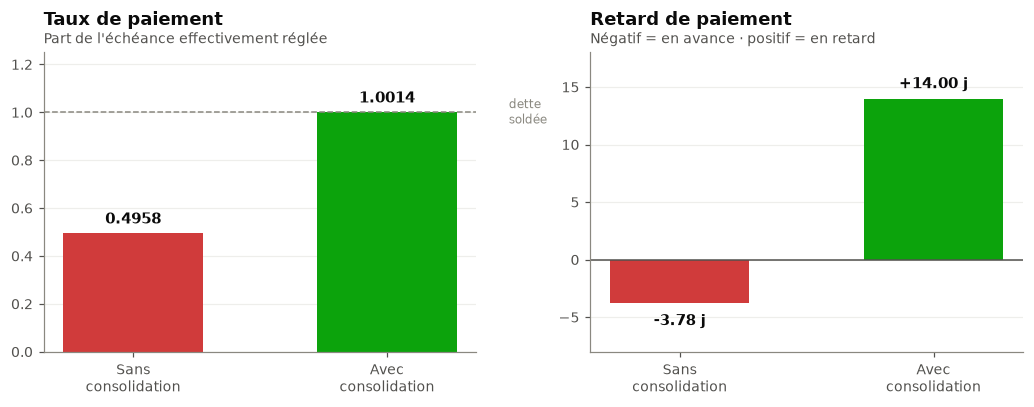

Échéances comptées sans consolidation : 13 605 401
Échéances réelles                     : 12 951 918
Écart                                 : 653 483


In [7]:
taux_sans = (valides.AMT_PAYMENT / valides.AMT_INSTALMENT).mean()
taux_avec = (consolide.paye_somme / consolide.du).mean()
retard_sans = (valides.DAYS_ENTRY_PAYMENT - valides.DAYS_INSTALMENT).mean()
retard_avec = (consolide.paye_jour_max - consolide.du_jour).mean()

fig, (g, d) = plt.subplots(1, 2, figsize=(9.5, 3.8))

# Forme retenue : deux panneaux séparés, et non un graphique à deux axes. Les
# deux mesures n'ont ni la même unité ni le même ordre de grandeur ; les
# superposer laisserait lire des rapports qui n'existent pas.
g.bar(["Sans\nconsolidation", "Avec\nconsolidation"], [taux_sans, taux_avec],
      color=[CRITIQUE, BON], width=0.55)
g.axhline(1.0, color=ENCRE_3, lw=1, ls="--")
g.text(1.48, 1.0, "dette\nsoldée", fontsize=8, color=ENCRE_3, va="center")
for i, v in enumerate([taux_sans, taux_avec]):
    g.text(i, v + 0.04, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)
g.set_ylim(0, 1.25)
habiller(g, "Taux de paiement", "Part de l'échéance effectivement réglée")

d.bar(["Sans\nconsolidation", "Avec\nconsolidation"], [retard_sans, retard_avec],
      color=[CRITIQUE, BON], width=0.55)
d.axhline(0, color=ENCRE_2, lw=1)
for i, v in enumerate([retard_sans, retard_avec]):
    d.text(i, v + (0.9 if v > 0 else -1.9), f"{v:+.2f} j",
           ha="center", fontweight="bold", fontsize=10)
d.set_ylim(-8, 18)
habiller(d, "Retard de paiement", "Négatif = en avance · positif = en retard")

plt.tight_layout(); plt.show()

print(f"Échéances comptées sans consolidation : {espace(len(instal))}")
print(f"Échéances réelles                     : {espace(taille.size)}")
print(f"Écart                                 : {espace(len(instal) - taille.size)}")

**Le signe du retard s'inverse.** Sans consolidation, ces clients paraissent
payer **en avance de 3,8 jours** ; en réalité ils soldent leur échéance avec
**14 jours de retard**. Et le taux de paiement passe de 0,50 à 1,00 : un client
qui règle l'intégralité de sa dette semblerait n'en payer que la moitié.

**Ce que ça décide.** Le pipeline consolide par échéance — somme des versements,
date du dernier — **avant** toute agrégation. Sans cette étape, le signal de
risque serait inversé sur la source la plus prédictive du modèle.

---

## 5. Les valeurs manquantes : une absence n'est pas un zéro

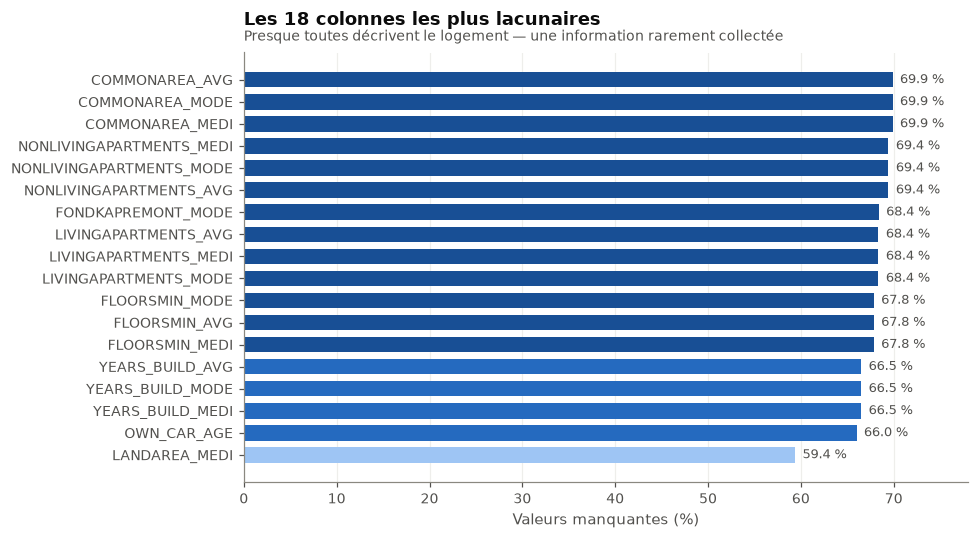

Colonnes avec au moins une valeur manquante : 67 sur 122
Colonnes au-dessus de 50 % de manquants     : 41


In [8]:
app = pd.read_csv(ENTREE / "application_train.csv", low_memory=False)
nuls = (app.isna().mean() * 100).sort_values(ascending=False)
top = nuls.head(18)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))

# La couleur encode ici une GRANDEUR (le taux lui-même), pas une identité :
# palette séquentielle à teinte unique, du clair au foncé. Une palette
# catégorielle laisserait croire à des groupes distincts.
normes = (top.values - top.values.min()) / (top.values.max() - top.values.min())
ax.barh(top.index, top.values,
        color=[SEQ[min(int(n * (len(SEQ) - 1)) + 1, len(SEQ) - 1)] for n in normes],
        height=0.7)
for i, v in enumerate(top.values):
    ax.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=8.5, color=ENCRE_2)

ax.set_xlim(0, 78)
habiller(ax, "Les 18 colonnes les plus lacunaires",
         "Presque toutes décrivent le logement — une information rarement collectée",
         axe_x="Valeurs manquantes (%)", grille="x")
plt.tight_layout(); plt.show()

print(f"Colonnes avec au moins une valeur manquante : {int((nuls > 0).sum())} sur {app.shape[1]}")
print(f"Colonnes au-dessus de 50 % de manquants     : {int((nuls > 50).sum())}")

**Ce que ça décide.** Aucune imputation. LightGBM apprend de quel côté envoyer
les valeurs absentes ; imputer par la médiane reviendrait à affirmer une valeur
inconnue et à effacer l'information portée par l'absence.

Cette information est substantielle : **14,3 % des dossiers n'ont aucun
historique au bureau de crédit**. Ce ne sont pas des clients sans dette, ce sont
des primo-emprunteurs — un profil de risque à part entière. Le pipeline produit
donc des indicateurs de présence explicites (`A_HISTORIQUE_BUREAU`,
`A_CARTE_CREDIT`, `A_DEMANDE_ANTERIEURE`) plutôt que de combler les trous.

---

## 6. Une valeur sentinelle qui déforme tout

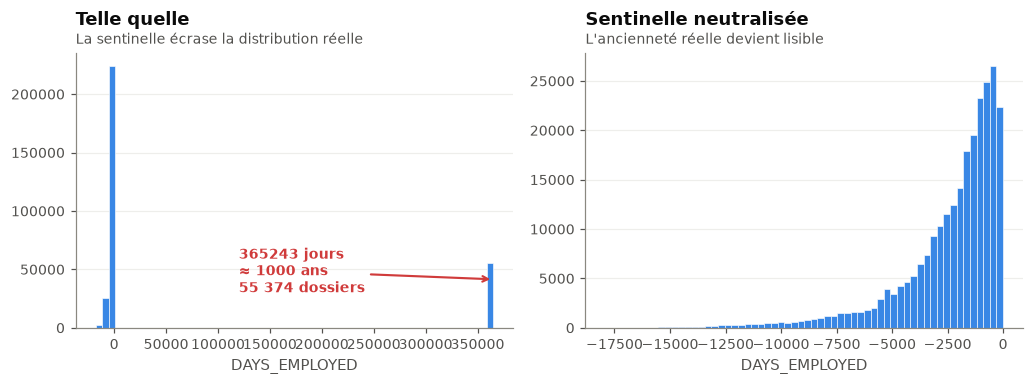

Dossiers portant la sentinelle : 55 374 (18.0 % du total)
Ancienneté médiane réelle      : 4.5 ans


In [9]:
emploi = app["DAYS_EMPLOYED"]
sentinelle = int((emploi == 365243).sum())

fig, (g, d) = plt.subplots(1, 2, figsize=(9.5, 3.6))

g.hist(emploi, bins=60, color=SEQ[3], edgecolor="white", linewidth=0.4)
g.annotate(f"365243 jours\n≈ 1000 ans\n{espace(sentinelle)} dossiers",
           xy=(365243, sentinelle * 0.75), xytext=(120000, sentinelle * 0.55),
           fontsize=9, color=CRITIQUE, fontweight="bold",
           arrowprops=dict(arrowstyle="->", color=CRITIQUE, lw=1.4))
habiller(g, "Telle quelle", "La sentinelle écrase la distribution réelle",
         axe_x="DAYS_EMPLOYED")

d.hist(emploi.replace(365243, np.nan).dropna(), bins=60,
       color=SEQ[3], edgecolor="white", linewidth=0.4)
habiller(d, "Sentinelle neutralisée", "L'ancienneté réelle devient lisible",
         axe_x="DAYS_EMPLOYED")

plt.tight_layout(); plt.show()

print(f"Dossiers portant la sentinelle : {espace(sentinelle)} "
      f"({sentinelle / len(app) * 100:.1f} % du total)")
print(f"Ancienneté médiane réelle      : {abs(emploi.replace(365243, np.nan).median()) / 365:.1f} ans")

**Ce que ça décide.** 365243 jours, soit près de mille ans d'ancienneté
professionnelle : c'est un code d'absence, employé pour les retraités et les
sans-emploi. Laissée telle quelle, la valeur écrase toute la distribution et
fausse chaque statistique qui en dépend.

Le pipeline la remplace par `NULL` **et** conserve l'information dans un
indicateur `DAYS_EMPLOYED_ANORMAL` : on efface la valeur absurde, pas le fait
qu'elle était là.

---

## 7. Les sept ratios métier, et leurs pièges

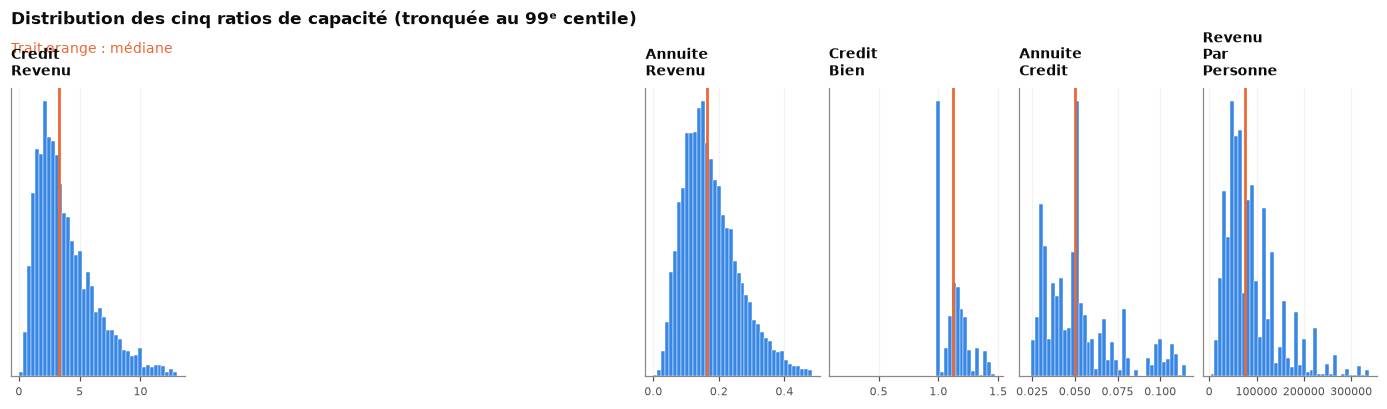

In [10]:
ratios = pd.DataFrame({
    "RATIO_CREDIT_REVENU": app.AMT_CREDIT / app.AMT_INCOME_TOTAL,
    "RATIO_ANNUITE_REVENU": app.AMT_ANNUITY / app.AMT_INCOME_TOTAL,
    "RATIO_CREDIT_BIEN": app.AMT_CREDIT / app.AMT_GOODS_PRICE,
    "RATIO_ANNUITE_CREDIT": app.AMT_ANNUITY / app.AMT_CREDIT,
    "REVENU_PAR_PERSONNE": app.AMT_INCOME_TOTAL / app.CNT_FAM_MEMBERS,
})

fig, axes = plt.subplots(1, 5, figsize=(12.5, 3.6), constrained_layout=True)

# Petits multiples : cinq distributions de même nature mais d'échelles très
# différentes. Les superposer sur un axe commun rendrait quatre d'entre elles
# illisibles ; un panneau par ratio conserve la comparaison de FORME.
for ax, nom in zip(axes, ratios.columns):
    serie = ratios[nom].replace([np.inf, -np.inf], np.nan).dropna()
    borne = serie.quantile(0.99)
    ax.hist(serie[serie <= borne], bins=40, color=SEQ[3],
            edgecolor="white", linewidth=0.3)
    ax.axvline(serie.median(), color=ORANGE, lw=1.8)
    ax.set_title(nom.replace("RATIO_", "").replace("_", "\n").title(),
                 fontsize=9, pad=8)
    ax.set_yticks([]); ax.grid(axis="x", alpha=0.5); ax.set_axisbelow(True)
    ax.tick_params(labelsize=7.5)

axes[0].text(0, 1.22, "Distribution des cinq ratios de capacité (tronquée au 99ᵉ centile)",
             transform=axes[0].transAxes, fontsize=11, fontweight="bold", color=ENCRE)
axes[0].text(0, 1.12, "Trait orange : médiane",
             transform=axes[0].transAxes, fontsize=9, color=ORANGE)
plt.show()

In [11]:
pieges = pd.DataFrame([
    ("AMT_INCOME_TOTAL = 0", int((app.AMT_INCOME_TOTAL == 0).sum()), "3 ratios → ∞"),
    ("AMT_GOODS_PRICE manquant", int(app.AMT_GOODS_PRICE.isna().sum()), "CREDIT_BIEN → NaN"),
    ("AMT_ANNUITY manquant", int(app.AMT_ANNUITY.isna().sum()), "2 ratios → NaN"),
    ("CNT_FAM_MEMBERS manquant", int(app.CNT_FAM_MEMBERS.isna().sum()), "REVENU_PAR_PERSONNE → NaN"),
    ("DAYS_REGISTRATION = 0", int((app.DAYS_REGISTRATION == 0).sum()), "ANCIENNETE → ∞"),
], columns=["Dénominateur problématique", "Dossiers", "Conséquence"])
pieges["Part"] = (pieges.Dossiers / len(app) * 100).map(lambda v: f"{v:.3f} %")
display(pieges[["Dénominateur problématique", "Dossiers", "Part", "Conséquence"]])

,Dénominateur problématique,Dossiers,Part,Conséquence
0,AMT_INCOME_TOTAL = 0,0,0.000 %,3 ratios → ∞
1,AMT_GOODS_PRICE manquant,278,0.090 %,CREDIT_BIEN → NaN
2,AMT_ANNUITY manquant,12,0.004 %,2 ratios → NaN
3,CNT_FAM_MEMBERS manquant,2,0.001 %,REVENU_PAR_PERSONNE → NaN
4,DAYS_REGISTRATION = 0,80,0.026 %,ANCIENNETE → ∞


**Ce que ça décide.** Cinq des sept ratios divisent par une colonne qui peut
valoir zéro ou manquer. Les volumes sont faibles — quelques centaines de dossiers
— mais chacun produirait un `inf` ou un `NaN` qui entrerait **silencieusement**
dans le feature store. Le pipeline protège donc chaque dénominateur, et le
contrôle qualité rejette toute valeur infinie.

---

## 8. Vingt indicateurs de documents, un seul utile ?

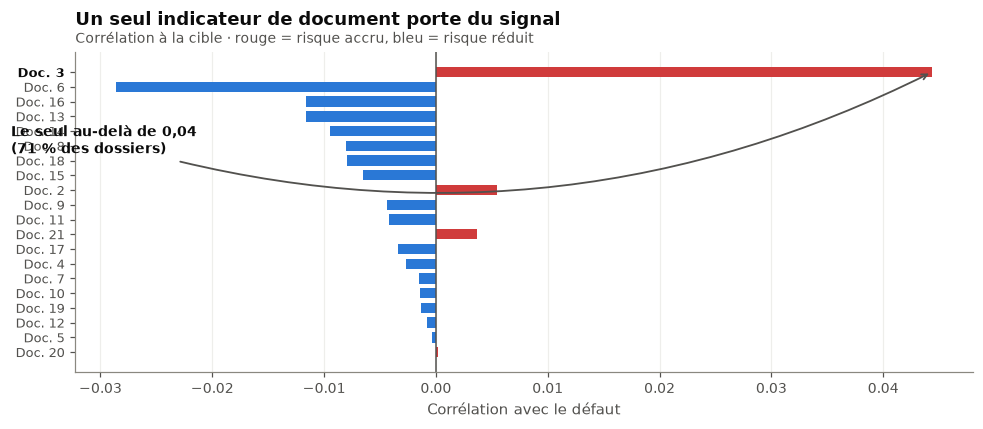

Indicateurs dont |corrélation| < 0,01 : 16 sur 20
Indicateurs présents dans moins de 1 % des dossiers : 16


In [12]:
flags = sorted((c for c in app.columns if c.startswith("FLAG_DOCUMENT_")),
               key=lambda c: int(c.rsplit("_", 1)[1]))
docs = pd.DataFrame({
    "variable": flags,
    "taux": [app[f].mean() * 100 for f in flags],
    "correlation": [app[f].corr(app.TARGET) for f in flags],
}).set_index("variable")

fig, ax = plt.subplots(figsize=(9, 4))
ordre = docs.correlation.abs().sort_values().index
valeurs = docs.loc[ordre, "correlation"]

# La couleur encode ici une POLARITÉ — corrélation positive ou négative — donc
# deux teintes opposées autour d'un zéro neutre, jamais un dégradé continu.
ax.barh(range(len(ordre)), valeurs,
        color=[CRITIQUE if v > 0 else BLEU for v in valeurs], height=0.7)
ax.axvline(0, color=ENCRE_2, lw=1)
ax.set_yticks(range(len(ordre)))
ax.set_yticklabels([n.replace("FLAG_DOCUMENT_", "Doc. ") for n in ordre], fontsize=8.5)

i3 = list(ordre).index("FLAG_DOCUMENT_3")
ax.get_yticklabels()[i3].set_fontweight("bold")
ax.get_yticklabels()[i3].set_color(ENCRE)
ax.annotate(f"Le seul au-delà de 0,04\n({docs.loc['FLAG_DOCUMENT_3', 'taux']:.0f} % des dossiers)",
            xy=(valeurs.iloc[i3], i3), xytext=(-0.038, i3 - 5.5),
            fontsize=9, color=ENCRE, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ENCRE_2, lw=1.2,
                            connectionstyle="arc3,rad=0.2"))

habiller(ax, "Un seul indicateur de document porte du signal",
         "Corrélation à la cible · rouge = risque accru, bleu = risque réduit",
         axe_x="Corrélation avec le défaut", grille="x")
plt.tight_layout(); plt.show()

faibles = docs[docs.correlation.abs() < 0.01]
print(f"Indicateurs dont |corrélation| < 0,01 : {len(faibles)} sur 20")
print(f"Indicateurs présents dans moins de 1 % des dossiers : {int((docs.taux < 1).sum())}")

**Ce que ça décide.** L'hypothèse laissée ouverte dans `plan_features.md` §2.4
est tranchée : `FLAG_DOCUMENT_3` est le seul à porter du signal. Les dix-neuf
autres sont soit quasi constants — présents dans moins de 1 % des dossiers — soit
sans lien avec le défaut.

Le pipeline conserve donc `FLAG_DOCUMENT_3` isolément et remplace les dix-neuf
autres par leur **somme**, `NB_DOCUMENTS`, qui mesure la complétude du dossier.
Vingt colonnes deviennent deux variables, sans perte de signal.

---

## Ce que l'analyse a changé dans le pipeline

| Section | Mesure | Décision |
|---|---|---|
| 1 | 8,07 % de défauts | AUC-PR et coût métier, jamais l'accuracy |
| 2 | 58 M de lignes, 3 granularités | Agréger avant de joindre |
| 3 | 94,1 % de couverture dossier | `installments` traitée en premier |
| 4 | 653 483 échéances fractionnées | Consolider — surtout pas supprimer |
| 5 | 67 colonnes lacunaires | Aucune imputation, indicateurs de présence |
| 6 | 55 374 sentinelles | Neutraliser en `NULL` + indicateur |
| 7 | 5 dénominateurs à risque | Protéger chaque division |
| 8 | 19 indicateurs sans signal | Une somme au lieu de vingt colonnes |

**Deux de ces décisions évitent une erreur silencieuse** — celle qui ne fait
échouer aucun test et se lit seulement dans des prédictions dégradées :
la consolidation des versements (section 4) et la neutralisation de la sentinelle
(section 6).

C'est ce qui justifie l'ordre de travail retenu : mesurer, décider, puis coder.